# 进阶实践项目 01 参考答案：轻量残差 U-Net、边界评价与测试时增强

本答案对应题目的患者级划分、模型与损失、补充指标和不确定性四个部分。选择轻量残差 U-Net 和 BCE-Dice，是为了在 Kaggle 有限时间内获得稳定基线；这不是唯一方案。Tversky、边界损失、3D U-Net、MC dropout 或模型集成都可能更适合其他研究重点。


> **实践定位**
>
> 这不是短时间代码竞赛，也不是以最高分数决定完成度的作业。可以只完成数据核对、基线、一个消融实验或一段严谨的失败分析。问题定义、文献依据、方法选择、验证设计、错误解释和下一步实验，重要性高于单一性能数值。
>
> 最终提交由两部分组成：当前 Notebook，以及一份设计报告。设计报告不是代码说明书，而是研究方案说明。参考答案只展示一种能够运行的方案，不代表唯一正确答案，也不意味着其中的模型一定最适合你的目标。

**参考答案不是唯一正确答案。** 其他方案只要问题定义、数据处理、验证和解释合理，同样可以成立。

## 对应题目 1：环境、随机性与输出目录

固定随机种子便于复查，但 GPU 算子仍可能存在非完全确定性。`QUICK_MODE=True` 只训练少量轮次，目的是验证数据—模型—评价链条；正式比较需要增加轮次并保存最佳验证模型。


In [1]:
from pathlib import Path
import json,random,re
import numpy as np, matplotlib.pyplot as plt
from PIL import Image
import torch,torch.nn as nn,torch.nn.functional as F
from torch.utils.data import Dataset,DataLoader
from sklearn.model_selection import GroupShuffleSplit
from scipy.ndimage import binary_erosion, distance_transform_edt
SEED=42;random.seed(SEED);np.random.seed(SEED);torch.manual_seed(SEED)
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu'); QUICK_MODE=True
OUT=Path('/kaggle/working') if Path('/kaggle').exists() else Path('outputs_adv01');OUT.mkdir(exist_ok=True)
print('device',DEVICE)


device cpu


## 对应题目 2：真实数据发现与演示回退

函数搜索 `_mask` 文件并寻找同名 MRI。患者文件夹名称作为分组 ID。只有在没有真实数据时才使用几何合成图，且结果标记为 `demo`。演示回退只证明代码可运行，不能支持医学结论。


In [2]:
def synthetic_pairs(n_patients=12,slices=4,size=64):
    data=[]; yy,xx=np.mgrid[:size,:size]
    for p in range(n_patients):
        for s in range(slices):
            rng=np.random.default_rng(p*100+s)
            img=rng.normal(.25,.05,(size,size))
            cy=size/2+rng.uniform(-8,8);cx=size/2+rng.uniform(-8,8);r=rng.uniform(4,12)
            mask=((yy-cy)**2+(xx-cx)**2<r*r).astype(np.float32) if s>0 else np.zeros((size,size),np.float32)
            img+=mask*rng.uniform(.35,.65); img=np.clip(img,0,1).astype(np.float32)
            data.append((img,mask,f'P{p:02d}'))
    return data

def find_real():
    fs=[]
    for root in [Path('/kaggle/input'),Path('/mnt/data')]:
        if root.exists():
            for ext in ('*.tif','*.tiff','*.png'):
                fs += list(root.glob('**/'+ext))
    out=[]
    for m in fs:
        if '_mask' not in m.stem.lower(): continue
        im=Path(str(m).replace('_mask',''))
        if im.exists(): out.append((im,m,m.parent.name))
    return out
real=find_real(); records=real if real else synthetic_pairs(); mode='real' if real else 'demo'
print(mode,'slices',len(records),'patients',len(set(r[2] for r in records)))


demo slices 48 patients 12


## 对应题目 3：患者级划分

两次 `GroupShuffleSplit` 只使用患者 ID 分组。断言用于检查训练、验证和测试患者没有重叠。真实研究还应保存患者清单，并比较各集合病灶大小和空切片比例。


In [3]:
groups=np.array([r[2] for r in records]); idx=np.arange(len(records))
if len(np.unique(groups))<6: raise ValueError('患者数过少，无法形成可靠的三集合划分。')
gss=GroupShuffleSplit(1,test_size=.30,random_state=SEED)
tr,tmp=next(gss.split(idx,groups=groups))
g2=GroupShuffleSplit(1,test_size=.50,random_state=SEED+1)
va_rel,te_rel=next(g2.split(tmp,groups=groups[tmp]));va=tmp[va_rel];te=tmp[te_rel]
assert set(groups[tr]).isdisjoint(groups[va])
assert set(groups[tr]).isdisjoint(groups[te])
assert set(groups[va]).isdisjoint(groups[te])
print('patients train/val/test:',len(set(groups[tr])),len(set(groups[va])),len(set(groups[te])))


patients train/val/test: 8 2 2


## 对应题目 4：Dataset 与预处理

真实图像被缩放到 64×64，以便快速运行。掩膜使用最近邻插值，避免产生中间标签。每张 MRI 在自身范围内标准化。该简化会丢失原始分辨率和体素间距，因此 HD95 只能以像素报告。


In [4]:
class DS(Dataset):
    def __init__(self,ids):self.ids=list(ids)
    def __len__(self):return len(self.ids)
    def __getitem__(self,k):
        r=records[self.ids[k]]
        if mode=='real':
            im=np.array(Image.open(r[0]).convert('L').resize((64,64)),np.float32)/255
            ma=np.array(Image.open(r[1]).convert('L').resize((64,64),Image.Resampling.NEAREST),np.float32)>0
        else: im,ma=r[:2]
        im=(im-im.mean())/(im.std()+1e-6)
        return torch.tensor(im[None],dtype=torch.float32),torch.tensor(ma[None],dtype=torch.float32),r[2]
trL=DataLoader(DS(tr),batch_size=8,shuffle=True);vaL=DataLoader(DS(va),batch_size=8);teL=DataLoader(DS(te),batch_size=8)


## 对应题目 5：模型、损失与训练

残差块把输入通过捷径加入卷积结果，降低浅层网络优化难度。BCE 提供逐像素分类信号，Dice 部分降低背景占比过大造成的影响。参考答案没有加入边界损失，以避免一次引入过多变量。


In [5]:
class Block(nn.Module):
    def __init__(self,a,b):
        super().__init__();self.c=nn.Sequential(nn.Conv2d(a,b,3,1,1),nn.BatchNorm2d(b),nn.ReLU(),nn.Conv2d(b,b,3,1,1),nn.BatchNorm2d(b));self.s=nn.Conv2d(a,b,1) if a!=b else nn.Identity()
    def forward(self,x):return F.relu(self.c(x)+self.s(x))
class UNet(nn.Module):
    def __init__(self):
        super().__init__();self.e1=Block(1,12);self.e2=Block(12,24);self.b=Block(24,48);self.d2=Block(48+24,24);self.d1=Block(24+12,12);self.o=nn.Conv2d(12,1,1)
    def forward(self,x):
        a=self.e1(x);b=self.e2(F.max_pool2d(a,2));c=self.b(F.max_pool2d(b,2));d=F.interpolate(c,scale_factor=2,mode='bilinear',align_corners=False);d=self.d2(torch.cat([d,b],1));d=F.interpolate(d,scale_factor=2,mode='bilinear',align_corners=False);return self.o(self.d1(torch.cat([d,a],1)))
def dice_prob(p,y):return (2*(p*y).sum((1,2,3))+1)/((p+y).sum((1,2,3))+1)
def loss_fn(z,y):
    p=torch.sigmoid(z);return F.binary_cross_entropy_with_logits(z,y)+(1-dice_prob(p,y).mean())
model=UNet().to(DEVICE);opt=torch.optim.Adam(model.parameters(),2e-3);hist=[];best=None;best_score=-1
for ep in range(3 if QUICK_MODE else 25):
    model.train();ls=[]
    for x,y,_ in trL:
        x=x.to(DEVICE);y=y.to(DEVICE);opt.zero_grad();l=loss_fn(model(x),y);l.backward();opt.step();ls.append(l.item())
    model.eval();ds=[]
    with torch.no_grad():
        for x,y,_ in vaL:ds+=dice_prob(torch.sigmoid(model(x.to(DEVICE))).cpu(),y).tolist()
    val=float(np.mean(ds));hist.append([float(np.mean(ls)),val]);print(ep,hist[-1])
    if val>best_score: best_score=val;best={k:v.detach().cpu().clone() for k,v in model.state_dict().items()}
model.load_state_dict(best)


0 [1.4820881187915802, 0.10033014371583704]


1 [1.266400694847107, 0.1351643596717622]
2 [1.1256333589553833, 0.21056326523103053]


<All keys matched successfully>

## 对应题目 6：Dice、HD95 与测试时增强

HD95 计算两条预测表面的双向距离第 95 百分位，减少单个离群点对最大 Hausdorff 距离的支配。水平翻转前后两次预测的差异用作简化稳定性信号；它只反映这一种扰动，不是校准概率。


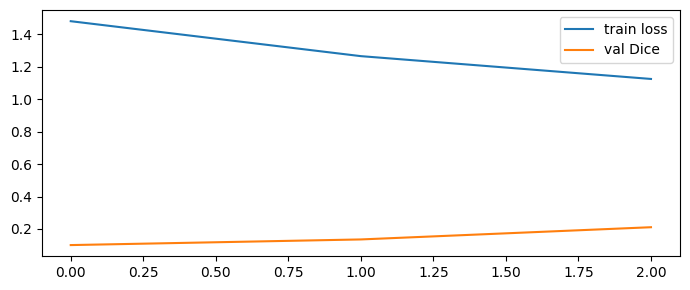

test mean Dice 0.9621325188533771


In [6]:
plt.figure(figsize=(7,3));plt.plot([x[0] for x in hist],label='train loss');plt.plot([x[1] for x in hist],label='val Dice');plt.legend();plt.tight_layout();plt.savefig(OUT/'adv01_curve.png',dpi=150);plt.show()
def hd95(a,b):
    a=a.astype(bool);b=b.astype(bool)
    if not a.any() and not b.any():return 0.
    if not a.any() or not b.any():return np.nan
    sa=a^binary_erosion(a);sb=b^binary_erosion(b);da=distance_transform_edt(~a);db=distance_transform_edt(~b);d=np.r_[db[sa],da[sb]];return float(np.percentile(d,95))
res=[];examples=[];model.eval()
with torch.no_grad():
  for x,y,g in teL:
    x=x.to(DEVICE);p1=torch.sigmoid(model(x));p2=torch.flip(torch.sigmoid(model(torch.flip(x,[3]))),[3]);p=(p1+p2)/2;unc=(p1-p2).abs()/2
    for k in range(len(g)):
      pb=(p[k,0].cpu().numpy()>.5);yb=y[k,0].numpy()>0.5
      d=float((2*(pb&yb).sum()+1)/(pb.sum()+yb.sum()+1));res.append({'patient':g[k],'dice':d,'hd95_px':hd95(pb,yb)});examples.append((x[k,0].cpu().numpy(),yb,pb,unc[k,0].cpu().numpy()))
case_dice=float(np.mean([r['dice'] for r in res]));print('test mean Dice',case_dice)


## 对应题目 7：病例图与结果文件

图中按 MRI、真值、预测和 TTA 差异排列。设计报告应选择具体病例解释，而不是只重复平均值。结果 JSON 保存每张测试切片的患者 ID、Dice 和像素 HD95，便于进一步按患者汇总。


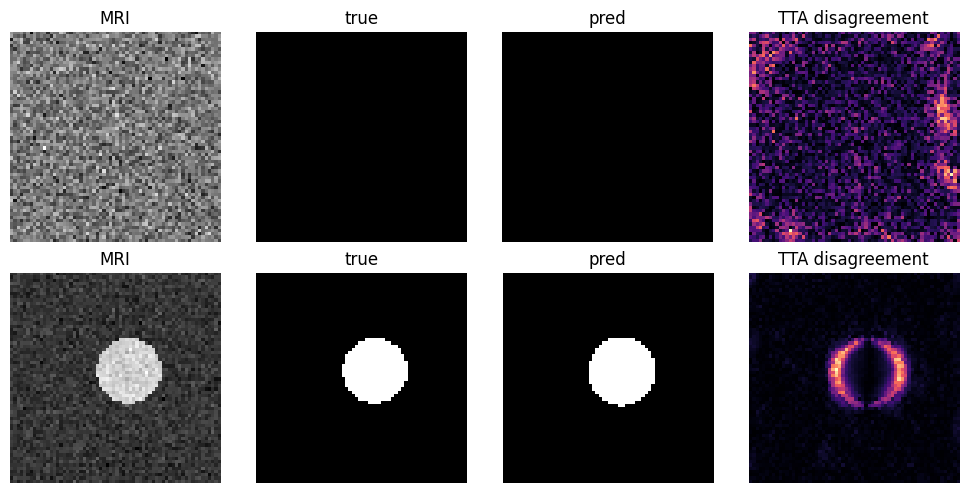

In [7]:
fig,ax=plt.subplots(2,4,figsize=(10,5))
for row,e in enumerate(examples[:2]):
    for j,(im,t) in enumerate(zip(e,['MRI','true','pred','TTA disagreement'])):
        ax[row,j].imshow(im,cmap='magma' if j==3 else 'gray');ax[row,j].set_title(t);ax[row,j].axis('off')
plt.tight_layout();plt.savefig(OUT/'adv01_prediction.png',dpi=150);plt.savefig(OUT/'adv01_uncertainty.png',dpi=150);plt.show()
patient_summary={}
for r in res: patient_summary.setdefault(r['patient'],[]).append(r['dice'])
patient_summary={k:float(np.mean(v)) for k,v in patient_summary.items()}
json.dump({'mode':mode,'mean_slice_dice':case_dice,'mean_patient_dice':float(np.mean(list(patient_summary.values()))),'patients':patient_summary,'cases':res},open(OUT/'adv01_result.json','w'),ensure_ascii=False,indent=2)


## 如何对应题目阅读本答案

- 数据获取与配对：第 2 部分；
- 患者级划分与泄漏检查：第 3 部分；
- 模型与损失选择：第 5 部分；
- Dice、边界与不确定性：第 6 部分；
- 病例解释与输出：第 7 部分。

其他合理答案可以使用 Tversky、边界损失、MC dropout、3D 网络或不同评价。关键是改变必须与研究问题对应，并在同一患者级测试条件下比较。

完整的示范研究说明见同目录 `项目01_参考设计报告.md`。其中包括研究问题、数据独立性、文献依据、方法选择、评价、结果解释、局限、下一步实验和本包运行记录。它仍然只是一种参考方案。